# Tech Challenge - Fase 1
## Case NPS Preditivo
Com o crescimento acelerado do e-commerce nacional, temos o cenário de uma empresa que passou a lidar com um volume cada vez maior de pedidos, entregas e interações com clientes. Esse crescimento trouxe ganhos importantes de escala, mas também revelou desafios relevantes na experiência do cliente, especialmente refletidos na alta variabilidade do Net Promoter Score (NPS) entre diferentes perfis de consumidores. A área de Experiência do Cliente percebeu que, mesmo com indicadores operacionais aparentemente semelhantes, alguns clientes se tornam promotores da marca, enquanto outros se tornam detratores.

Essa diferença levanta uma questão central para o negócio: quais fatores operacionais realmente influenciam a satisfação do cliente e como a empresa
pode agir de forma proativa para melhorar a experiência antes mesmo da aplicação da pesquisa de NPS?

## Dicionário de Dados
- customer_id: Identificador único do cliente.
- order_id: Identificador único do pedido.
- customer_age: Idade do cliente.
- customer_region: Região geográfica do cliente.
- customer_tenure_months: Tempo de relacionamento do cliente com a empresa (em meses).
- order_value: Valor total do pedido.
- items_quantity: Quantidade de itens no pedido.
- discount_value: Valor de desconto aplicado ao pedido.
- payment_installments: Número de parcelas do pagamento.
- delivery_time_days: Tempo total de entrega (em dias).
- delivery_delay_days: Quantidade de dias de atraso na entrega.
- freight_value: Valor do frete.
- delivery_attempts: Número de tentativas de entrega.
- customer_service_contacts: Número de contatos do cliente com o atendimento.
- resolution_time_days: Tempo para resolução de problemas (em dias).
- complaints_count: Número de reclamações registradas pelo cliente.
- repeat_purchase_30d: Indica se houve recompra em até 30 dias após o pedido (0 = não, 1 = sim).
- csat_internal_score: Score interno de satisfação do cliente.
- nps_score: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada
após a experiência de compra.

---
# 1 - Leitura inicial da base e import das Libs


In [1]:
#Libs para manipulação e leitura
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Cria data frame original
data_frame_original = pd.read_csv('../data/raw/desafio_nps_fase_1.csv')

#Leitura do head
data_frame_original.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
#Informacoes adicionais
data_frame_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

Tamanho do DF:
- 2500 linhas
- 19 colunas

In [4]:
#Estatisticas Basicas
data_frame_original.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.500000,721.832160,1.00,625.7500,1250.500,1875.2500,2500.00
customer_age,2500.0,43.396000,14.888487,18.00,31.0000,43.000,56.0000,69.00
customer_tenure_months,2500.0,61.322400,34.478729,1.00,31.0000,62.000,91.0000,119.00
order_id,2500.0,51250.500000,721.832160,50001.00,50625.7500,51250.500,51875.2500,52500.00
order_value,2500.0,434.259740,289.772497,7.76,220.2450,375.515,577.2900,1983.81
items_quantity,2500.0,3.470800,1.687331,1.00,2.0000,3.000,5.0000,6.00
discount_value,2500.0,29.745620,29.225603,0.02,8.8850,20.935,40.8325,230.33
payment_installments,2500.0,6.004000,3.159743,1.00,3.0000,6.000,9.0000,11.00
delivery_time_days,2500.0,8.022000,3.770411,2.00,5.0000,8.000,11.0000,14.00
delivery_delay_days,2500.0,2.187200,1.454442,0.00,1.0000,2.000,3.0000,8.00


In [5]:
#Contagem de Nullos
data_frame_original.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [7]:
#Contagem de valores duplicados
data_frame_original.duplicated().sum()

np.int64(0)

In [ ]:
#Valores unicos por variavel
data_frame_original.nunique()

customer_id                  2500
customer_age                   52
customer_region                 5
customer_tenure_months        119
order_id                     2500
order_value                  2457
items_quantity                  6
discount_value               2050
payment_installments           11
delivery_time_days             13
delivery_delay_days             9
freight_value                1897
delivery_attempts               3
customer_service_contacts       8
resolution_time_days           12
nps_score                     101
repeat_purchase_30d             2
complaints_count               12
csat_internal_score            98
dtype: int64

---
# 2 - Analises Graficas

## 2.1 - Analise da distribuição das variáveis númericas

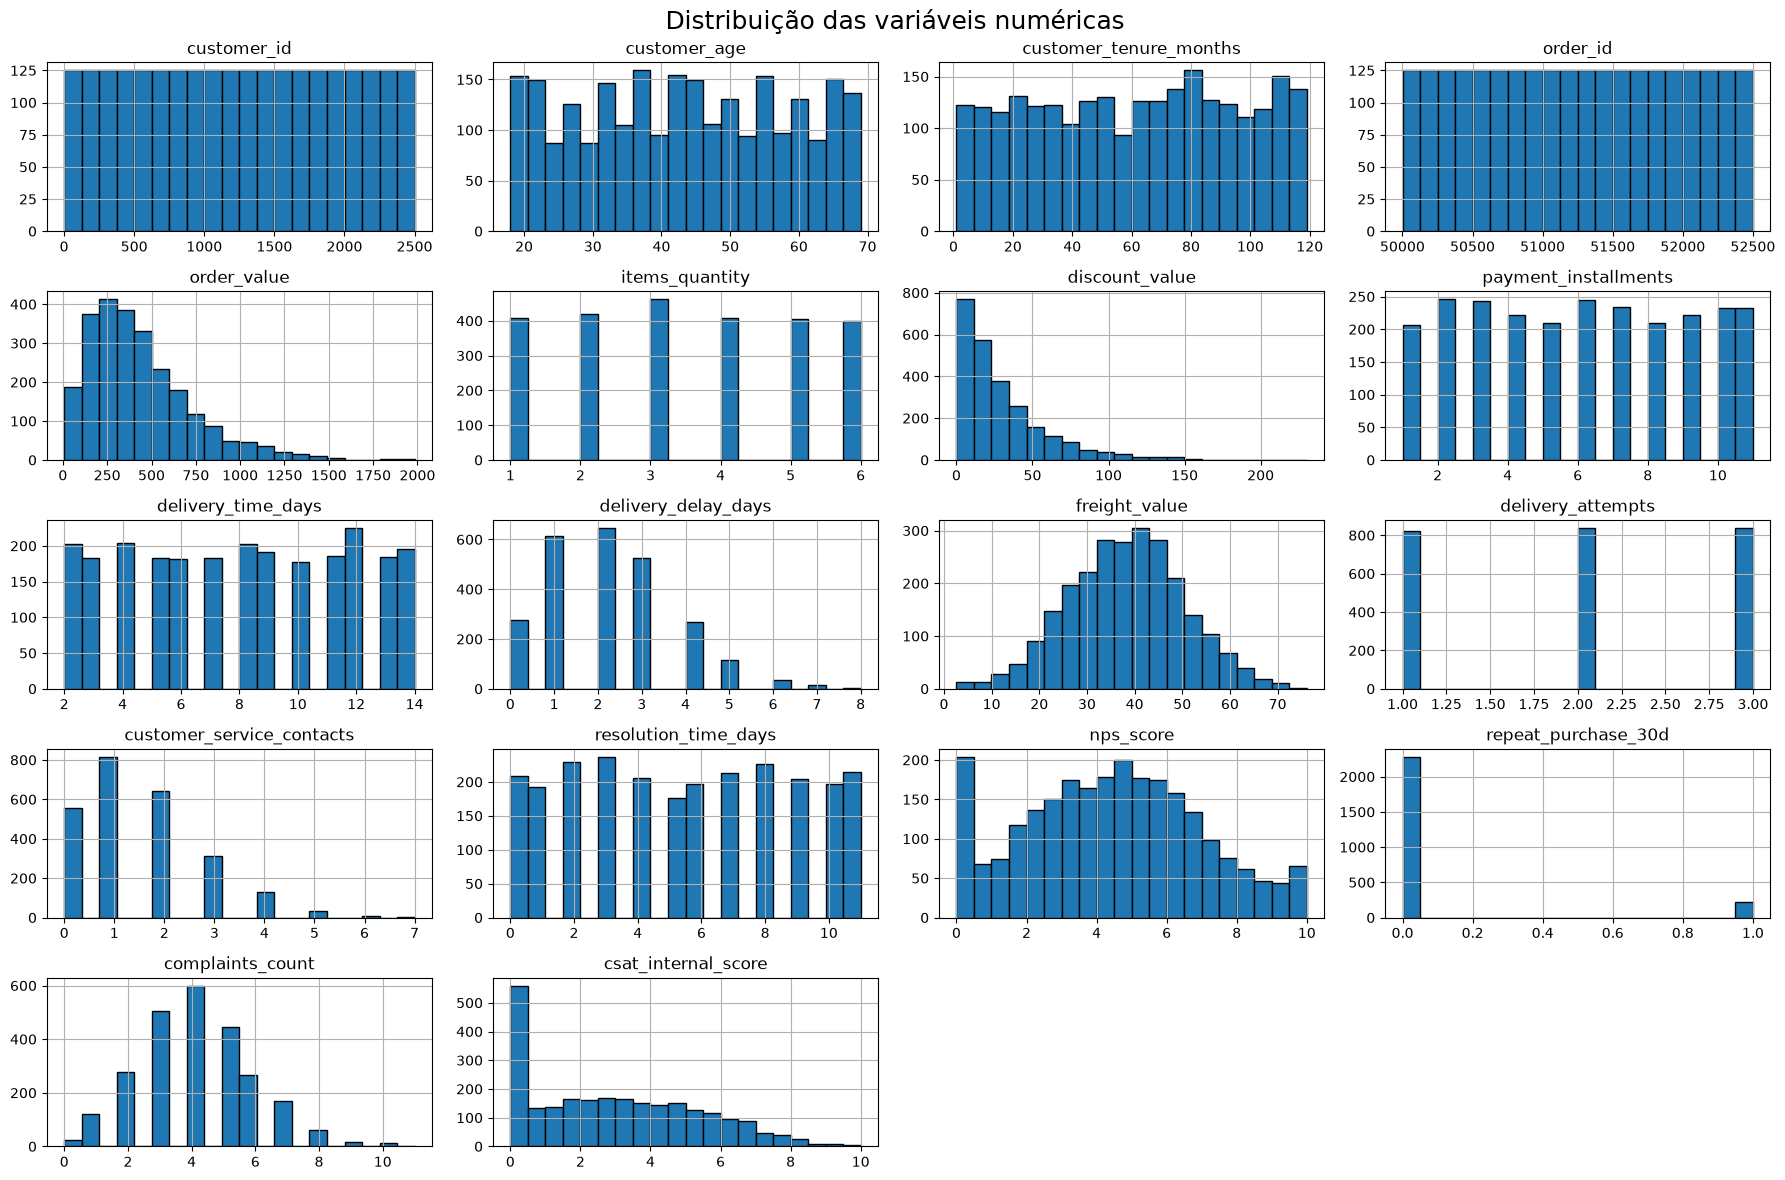

In [9]:
numericas = data_frame_original.select_dtypes(include="number").columns

data_frame_original[numericas].hist(
    figsize=(18, 12),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribuição das variáveis numéricas", fontsize=18)
plt.tight_layout()

## 2.2 - Distribuição das variáveis categoricas

/var/folders/nz/6_ly48yd4vg2cpdb788sdclh0000gn/T/ipykernel_10156/4208594300.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = data_frame_original.select_dtypes(include="object").columns


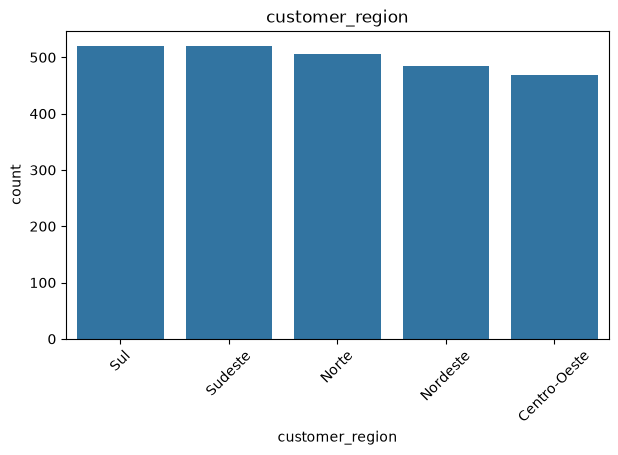

In [10]:
categoricas = data_frame_original.select_dtypes(include="object").columns

for coluna in categoricas:
    plt.figure(figsize=(7,4))

    sns.countplot(
        data=data_frame_original,
        x=coluna,
        order=data_frame_original[coluna].value_counts().index
    )

    plt.title(coluna)
    plt.xticks(rotation=45)
    plt.show()

## 2.3 - Boxplot

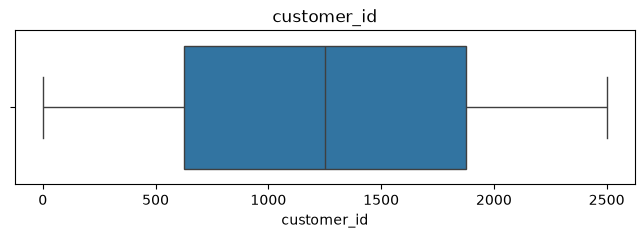

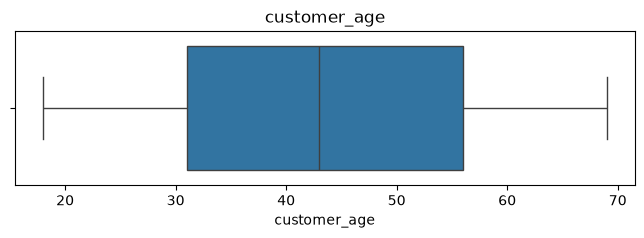

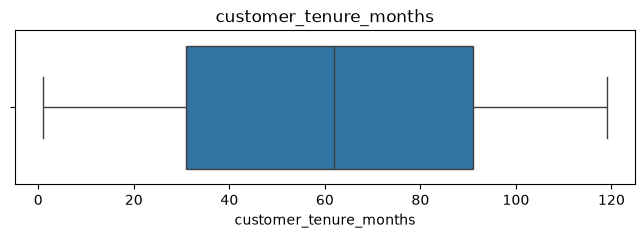

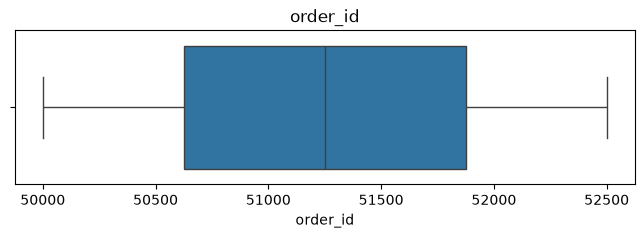

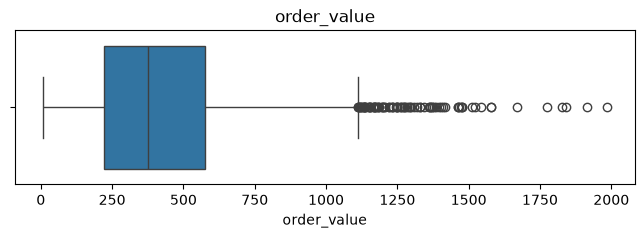

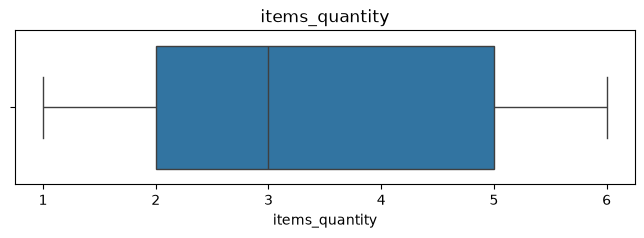

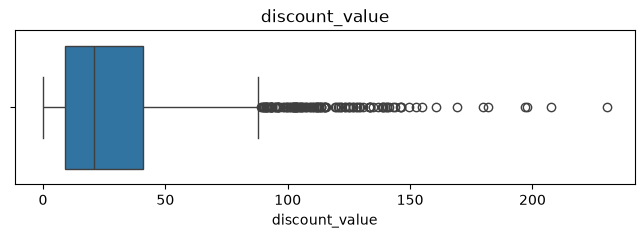

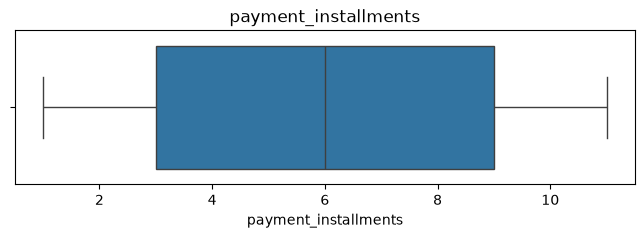

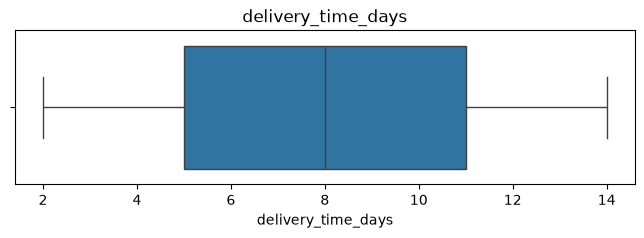

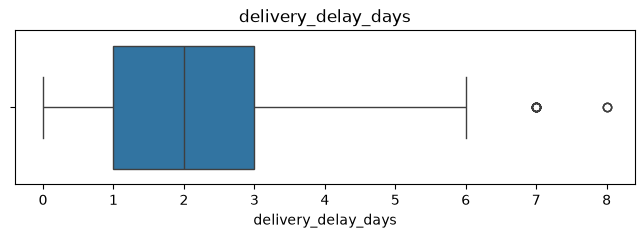

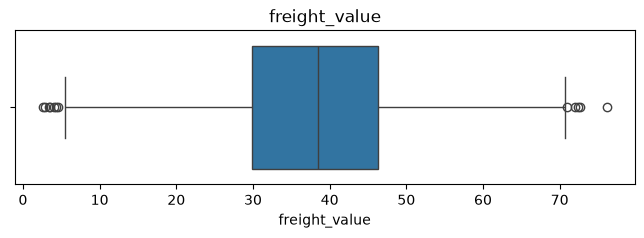

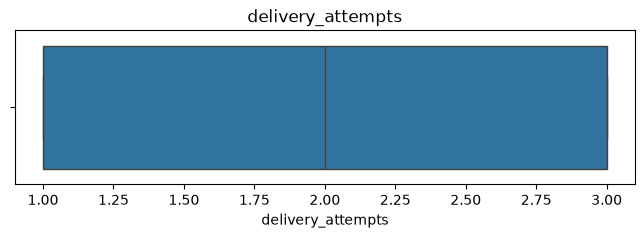

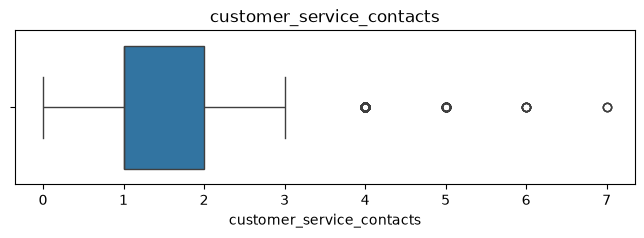

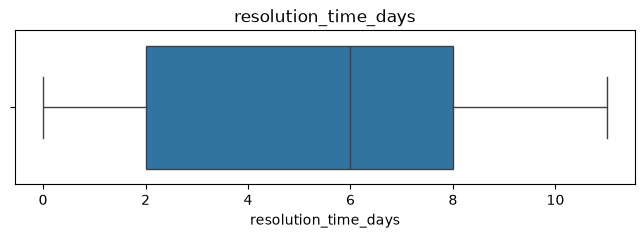

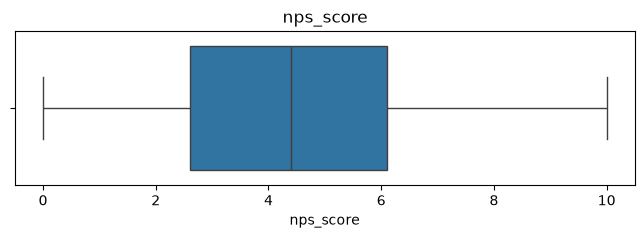

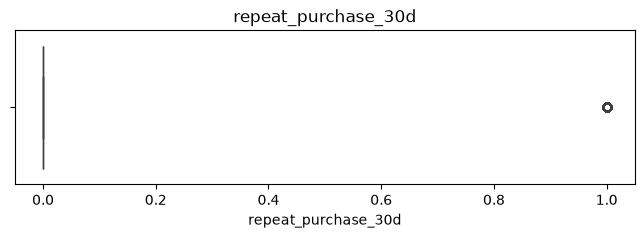

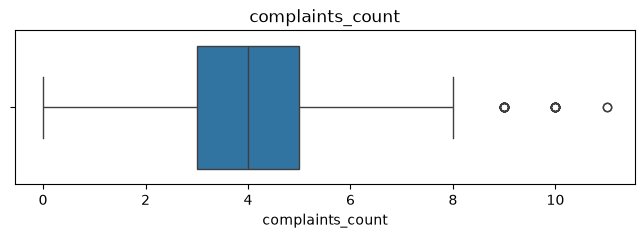

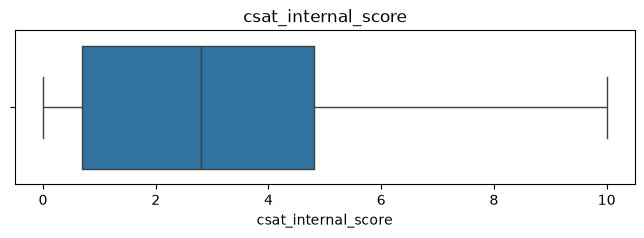

In [ ]:
for coluna in numericas:
    plt.figure(figsize=(8,2))
    sns.boxplot(
        x=data_frame_original[coluna]
    )

    plt.title(coluna)
    plt.show()

- ***nps_score***: é possivel identificar que o nosso NPS esta concentrado entre as notas 4, 5 e 6. Oque pode ser uma mal sinal, visto que a media esta baixa.
- ***delivery_delay_days***: é possivel identificar entregas que tiveram um delay muito grande na entrega, oque pode estar correlacionado diretamente com o NPS.

## 2.4 - Relações com NPS


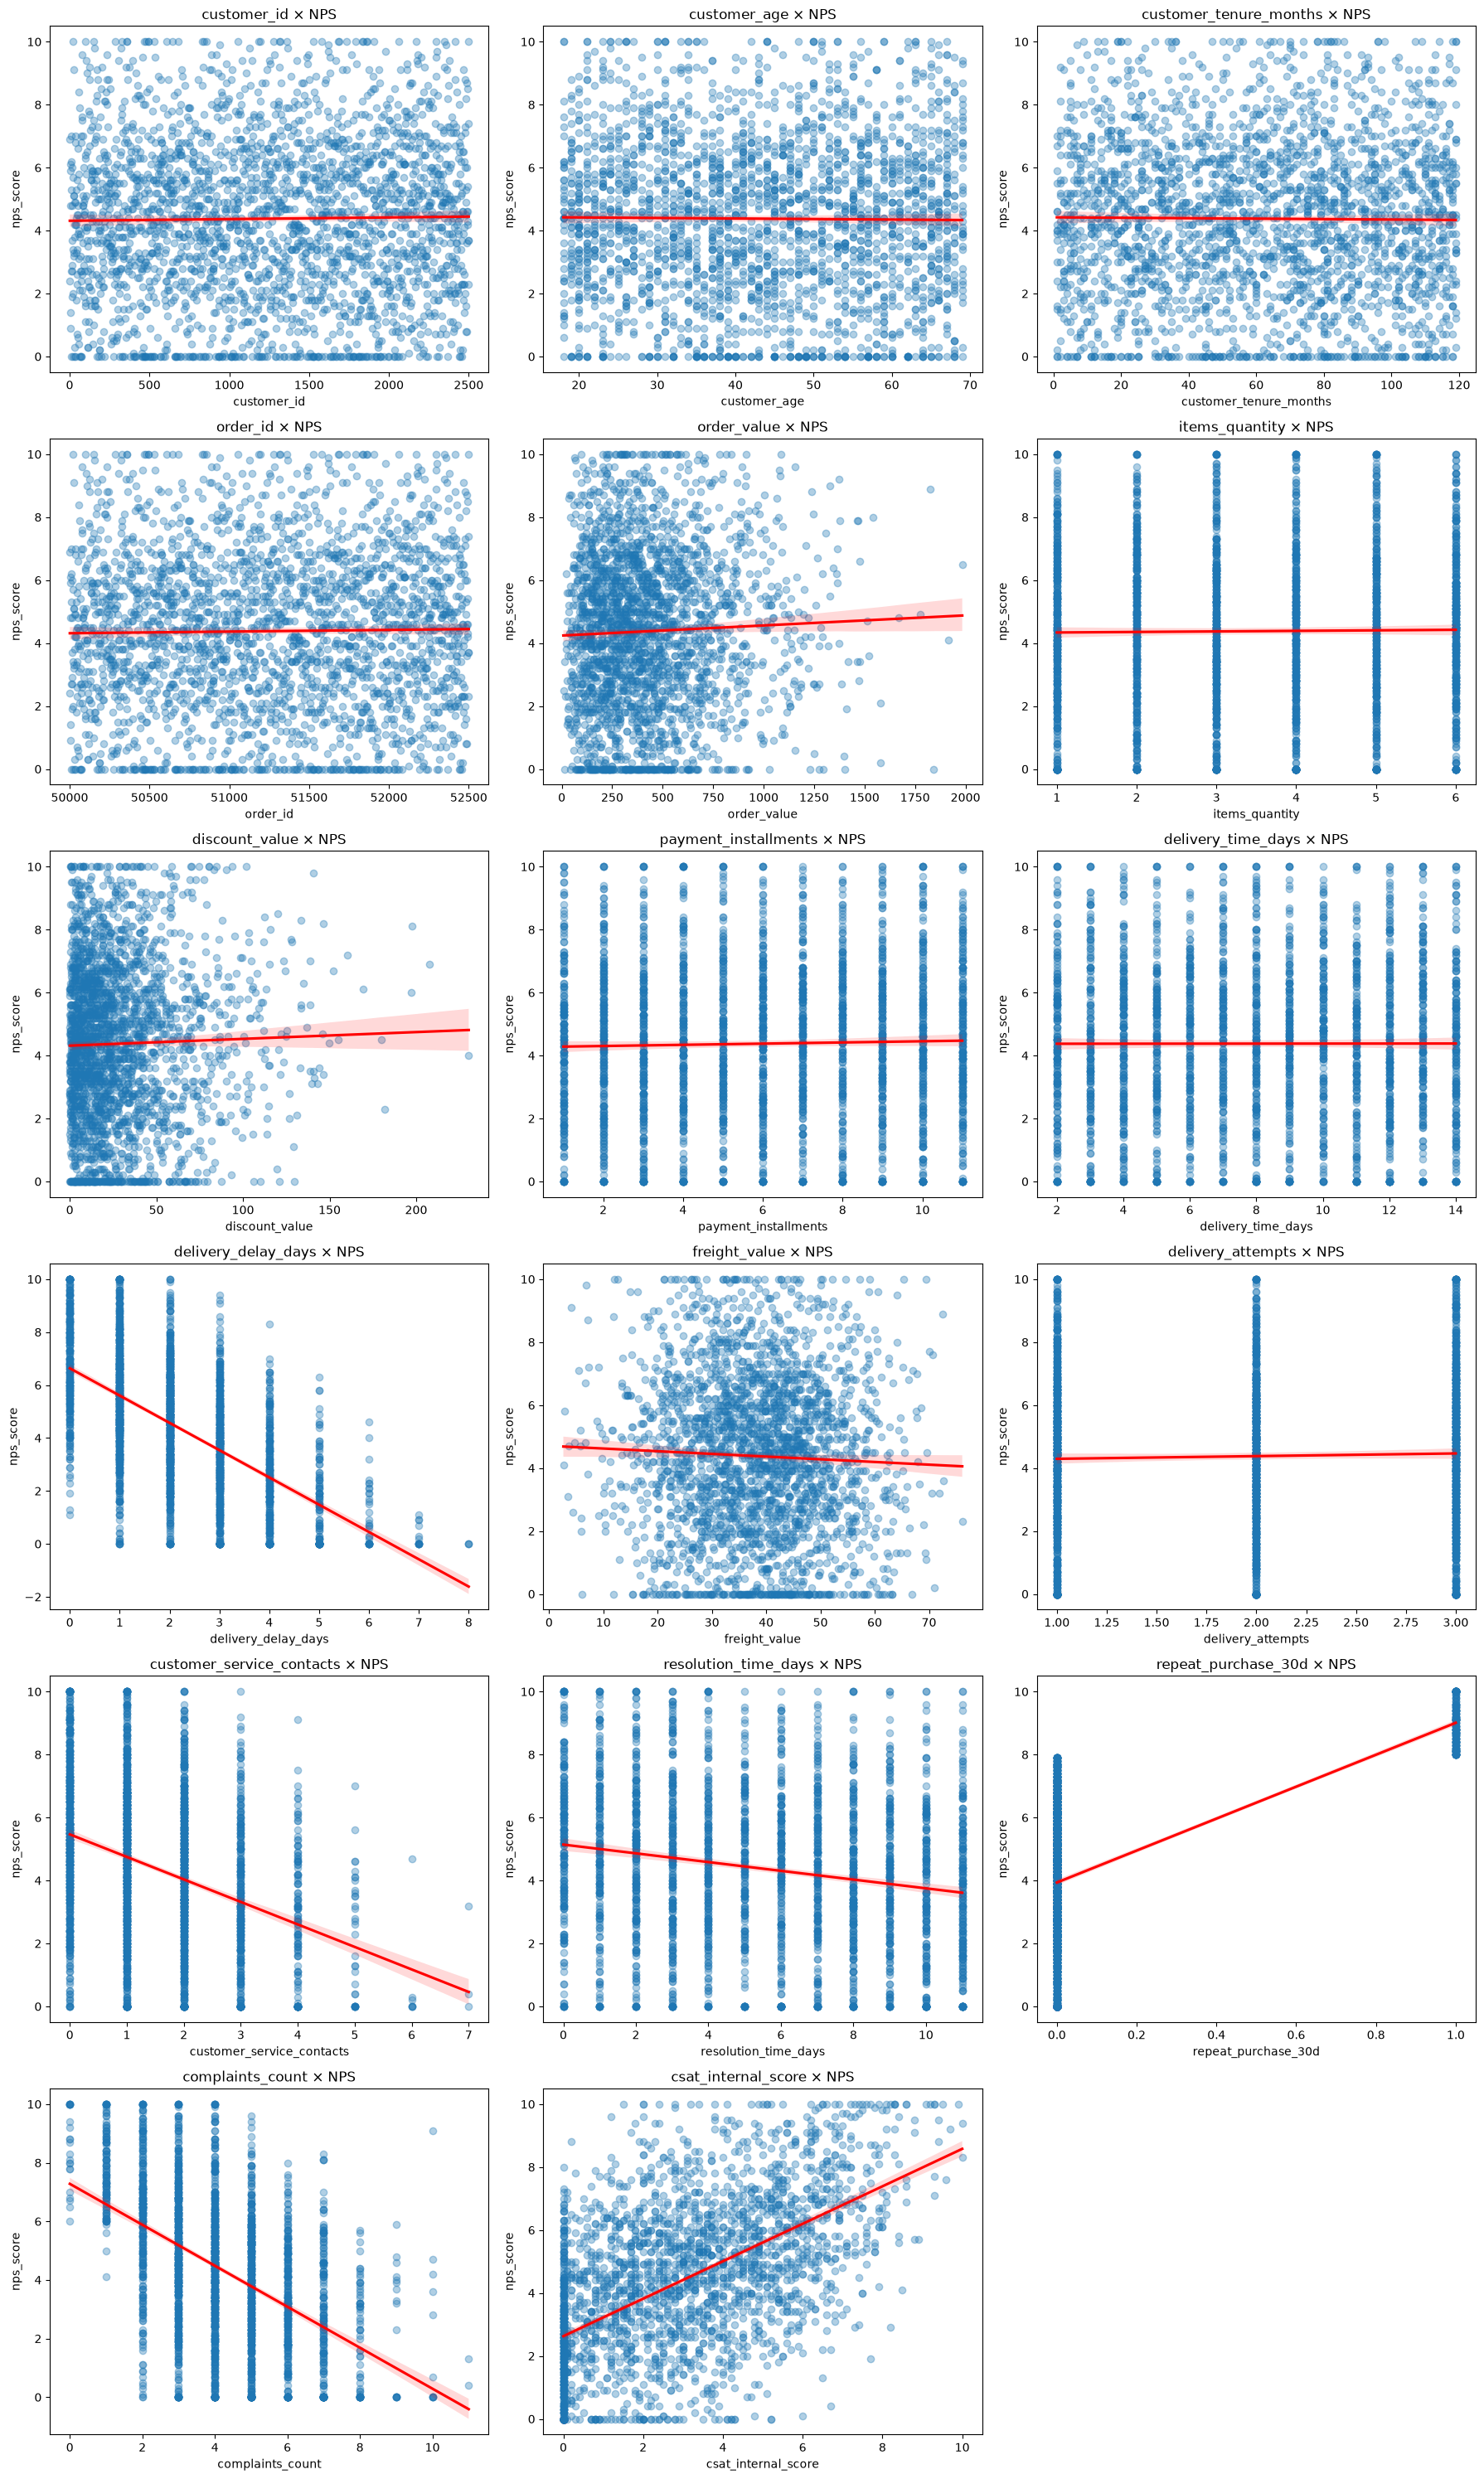

In [24]:
import math

numericas = data_frame_original.select_dtypes(include="number").columns.drop("nps_score")

n_cols = 3
n_rows = math.ceil(len(numericas) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for ax, coluna in zip(axes, numericas):

    sns.regplot(
        data=data_frame_original,
        x=coluna,
        y="nps_score",
        scatter_kws={"alpha":0.35},
        line_kws={"color":"red"},
        ax=ax
    )

    ax.set_title(f"{coluna} × NPS")

for ax in axes[len(numericas):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

---

---
# Hipóteses levantadas

A exploração inicial permitiu levantar algumas hipóteses que serão investigadas durante a Análise Exploratória de Dados (EDA). Estas hipóteses representam possíveis relações entre variáveis operacionais e a satisfação do cliente, sem assumir causalidade.

- Hipótese 1
Clientes que sofreram maiores atrasos na entrega tendem a apresentar menores notas de NPS.

- Hipótese 2
Quanto maior o número de contatos com o atendimento, menor tende a ser o NPS.

- Hipótese 3
Clientes com maior número de reclamações tendem a avaliar a experiência de forma mais negativa.

- Hipótese 4
Longos tempos de resolução de problemas podem estar associados à redução da satisfação do cliente.

- Hipótese 5
Clientes com maior CSAT interno tendem a apresentar maiores notas de NPS.

- Hipótese 6
Clientes que realizaram recompra em até 30 dias podem apresentar níveis de satisfação superiores aos clientes que não retornaram.

- Hipótese 7
Pedidos com maior tempo total de entrega podem estar associados a menores avaliações de satisfação.

- Hipótese 8
O perfil do cliente (idade, região e tempo de relacionamento) pode influenciar a percepção da experiência de compra.


---
# Limitação da análise

As relações observadas durante esta exploração representam associações estatísticas entre as variáveis e o NPS.

Entretanto, correlação não implica causalidade. A presença de uma associação entre duas variáveis não significa que uma seja responsável pela alteração da outra.

Diversos fatores da jornada do cliente podem ocorrer simultaneamente (atrasos, reclamações, contatos com o atendimento e tempo de resolução), tornando impossível afirmar, apenas com base na EDA, qual variável é a causa direta da satisfação ou da insatisfação.

Essas relações serão utilizadas como hipóteses para investigação nas próximas etapas do projeto.


---
# Conclusões do Playground

A exploração inicial permitiu compreender a estrutura da base de dados e identificar características importantes para as próximas etapas do projeto.

De forma geral, observou-se que:

- A base apresenta boa qualidade inicial para análise, sem problemas relevantes de estrutura.
- Existem variáveis relacionadas às dimensões de cliente, pedido, logística e atendimento, permitindo analisar diferentes aspectos da jornada do consumidor.
- Algumas variáveis aparentam possuir associação com o NPS, principalmente aquelas relacionadas à logística e ao atendimento.
- Foram identificados possíveis outliers em algumas variáveis numéricas, que serão avaliados durante a etapa de preparação dos dados.
- As correlações observadas servem como indícios para investigação, mas não permitem concluir relações de causa e efeito.

A partir desta exploração inicial, a próxima etapa será dedicada ao entendimento do problema de negócio e, posteriormente, à preparação dos dados e à Análise Exploratória (EDA), onde as hipóteses levantadas serão investigadas de forma mais aprofundada.